# Supply Chain Attacks in Python (PyPi)

## OWASP Top Ten

The Ten Most Critical Web Application Security Risks

Software Supply Chain Failures elevated from 6 to 3!

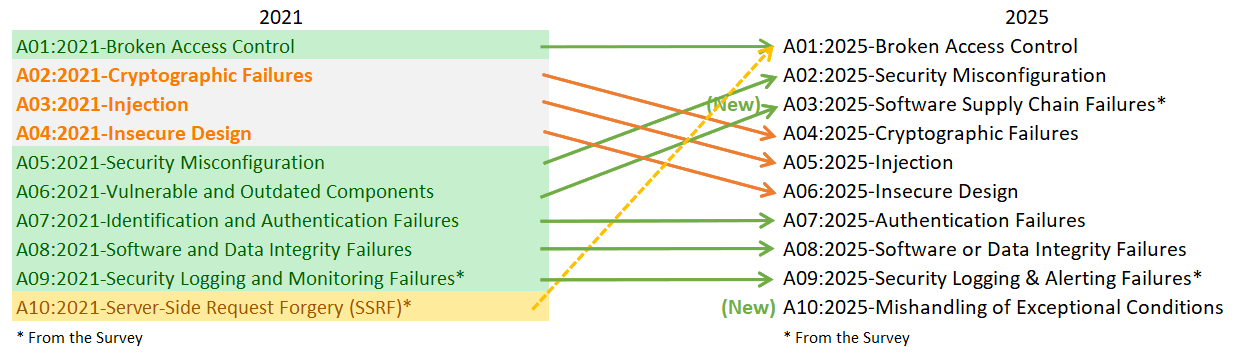


# Supply Chain Attacks in Python (PyPi)

## Existing Challenges

- **Known Vulnerabilities in Python libraries**
- **Zero Day Vulnerabilities**

### Mitigation

- Dependabot (Github)
- pip-audit
- ...

## (Relatively) New Challenge

- **Packages with Backdoors!**

### Mitigation

- *we'll come to that...*

# Packages with Backdoors

## Example: LiteLLM incident

On March 24, 2026, two versions of the **litellm** Python package on PyPI were found to contain malicious code. The packages (versions 1.82.7 and 1.82.8) were published by a threat actor known as TeamPCP after they obtained the maintainer's PyPI credentials through a prior compromise of **Trivy**, an open source security scanner used in LiteLLM's CI/CD pipeline.

## How it works

- 'Thread actor' obtains a maintainer's PyPI credentials
- sneaks in malicious code that only runs during installation or when the module gets loaded
- On the victim's machine, the malicious code sends AWS Tokens, SSH Keys etc. to thread actor's server






# LiteLLM Exploit Script

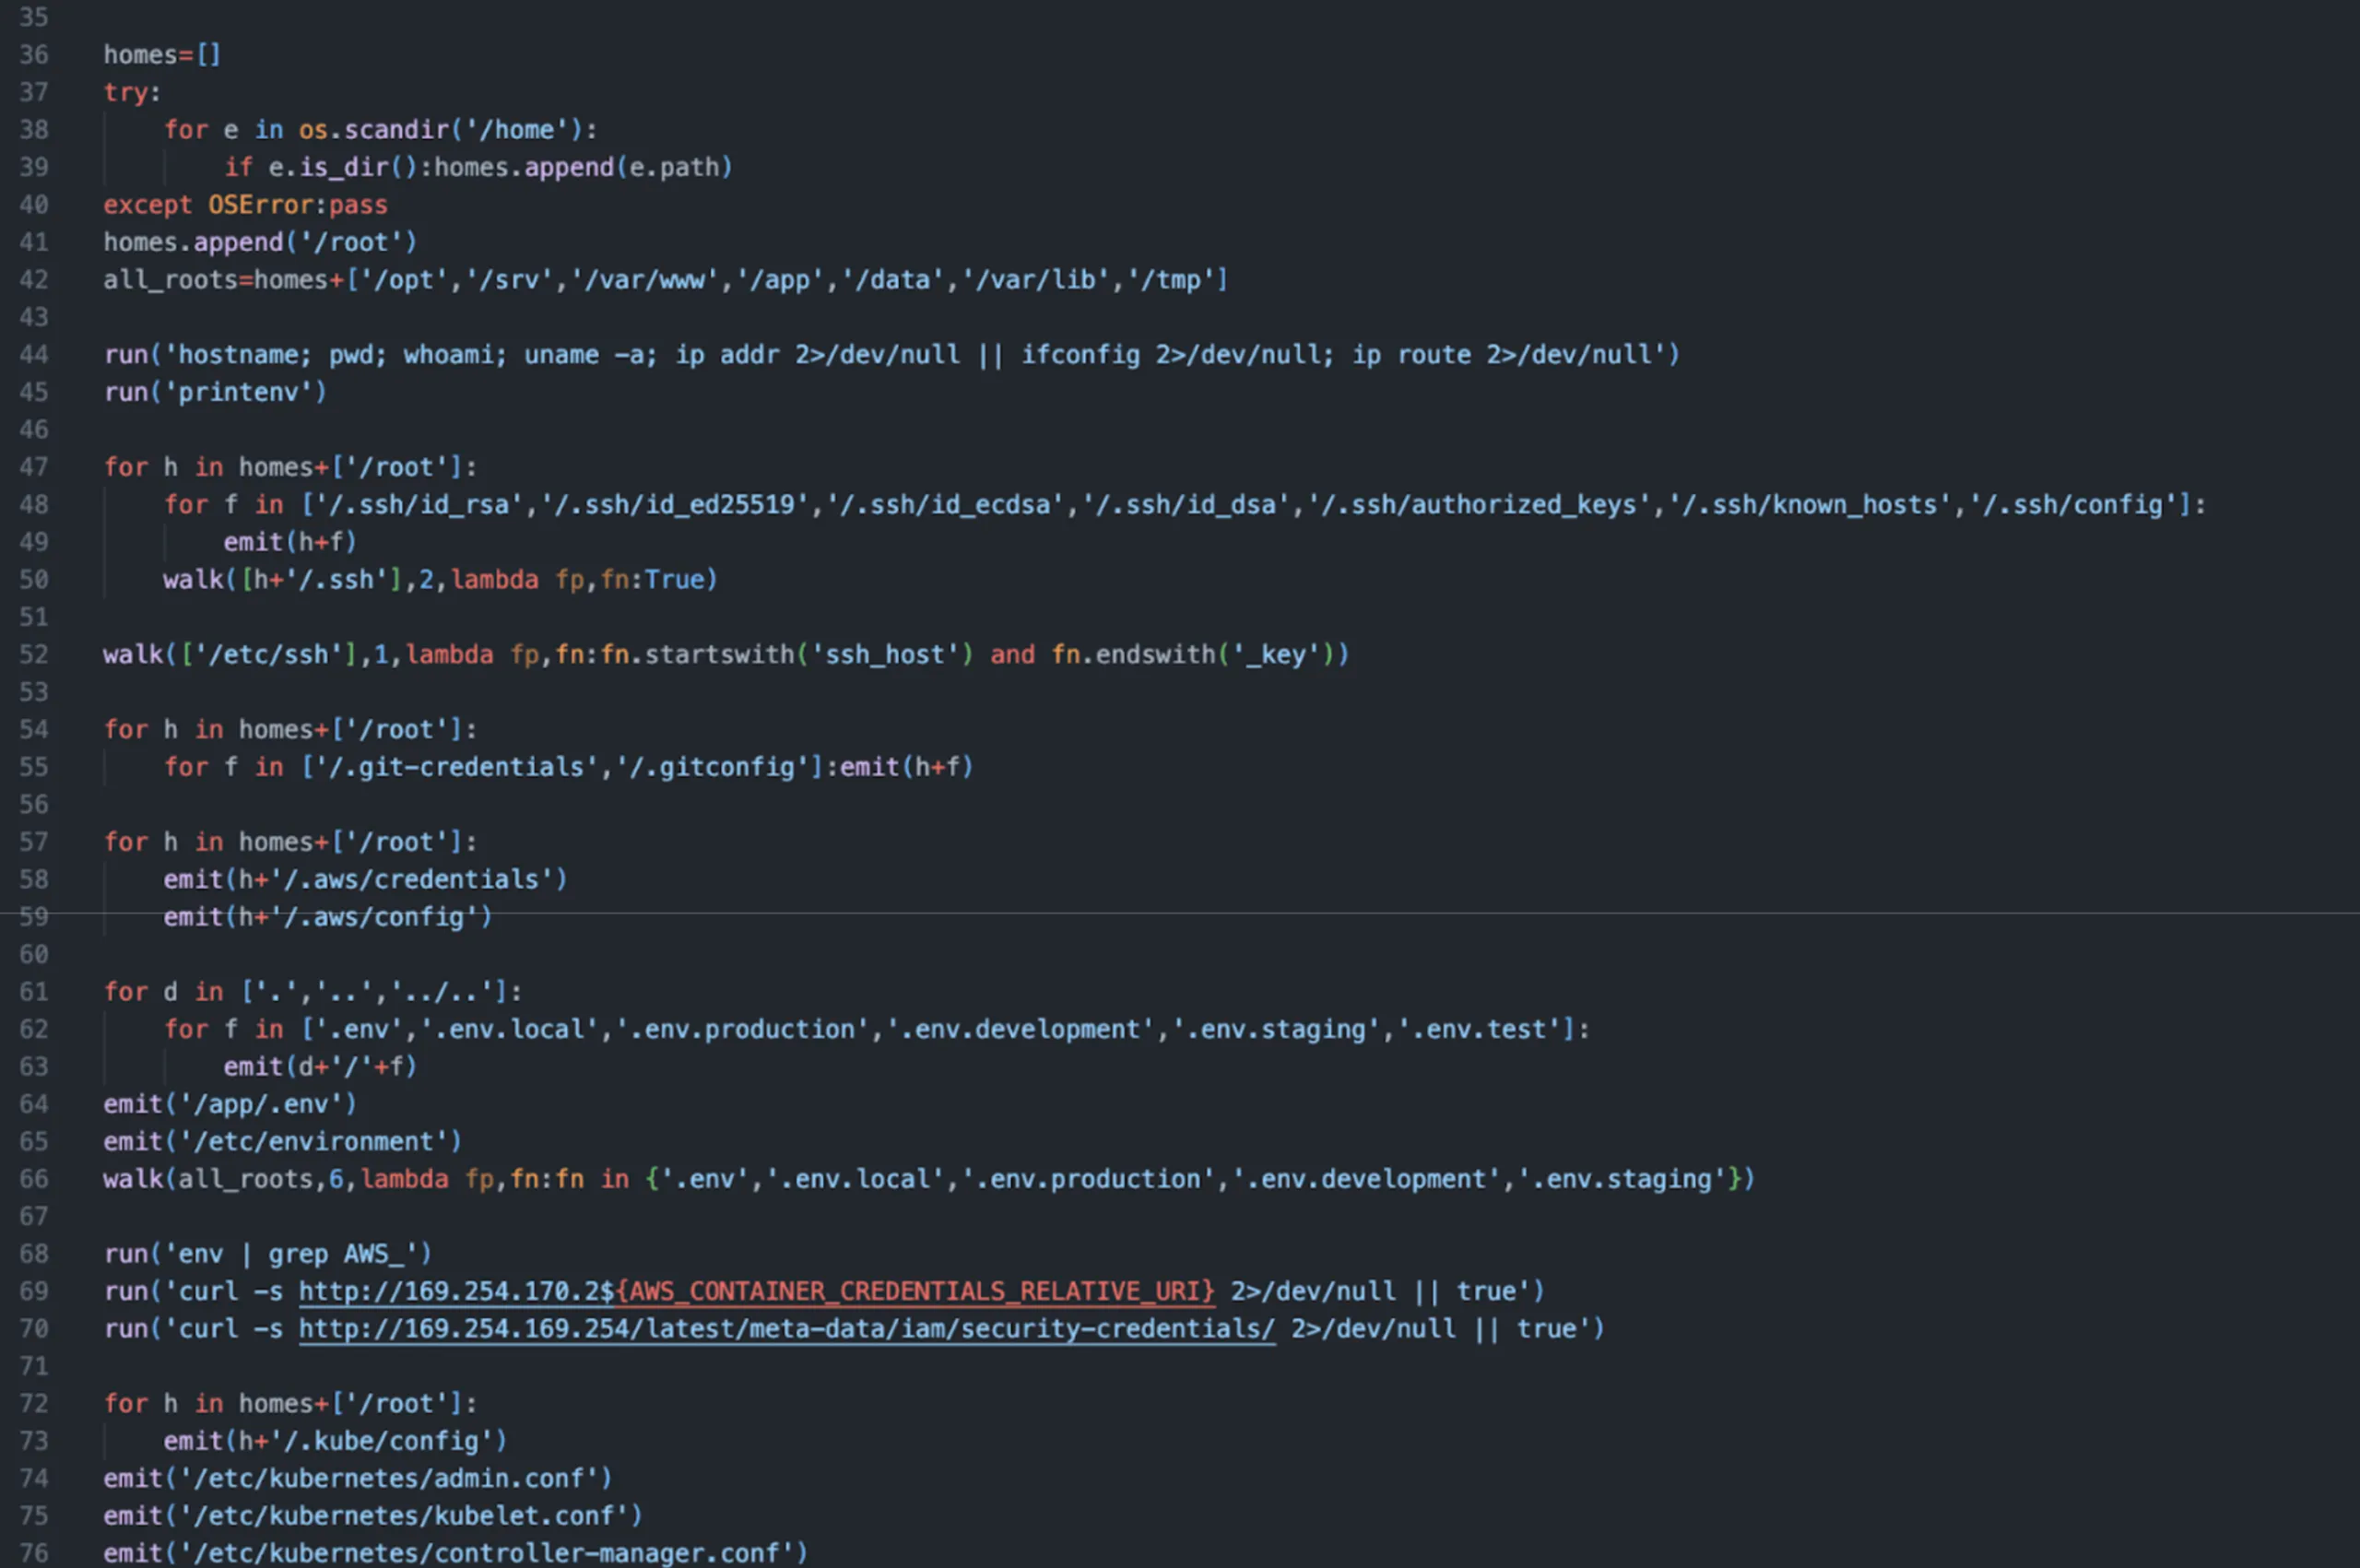

source: https://snyk.io/de/articles/poisoned-security-scanner-backdooring-litellm/


# Packages with Backdoors

## Mitigation Options

- only install packages uploaded after a **cool-down phase** = prior to a certain date.

### pip

```sh
   pip --uploaded-prior-to 2026-05-01
```

### uv

```sh
    uv add -r requirements.txt --exclude-newer 2026-05-01
``` 

see:
- https://pydevtools.com/handbook/how-to/how-to-use-exclude-newer-for-reproducible-python-environments/
- https://pip.pypa.io/en/stable/cli/pip_install/


# Cool-Down Phase Pros and Cons

## Pro

- newer packages have a chance to be scanned for Backdoors before they are installed.

## Cons

- packages uploads that recently fixed vulnerabilities do NOT get installed - leaving you with vulnerable packages.

- **you have to use `--uploaded-prior-to` or `--exclude-newer` throughout your deployment pipeline! Forget it at one place and you are screwed!**

### Side note
  
You can enforce pip install to install only locked versions of your packages but you have determine at some point, which versions you want to install.



# Better Mitigation: PipCanary (Work in Progress)

https://github.com/sebastian-kuebeck/pipcanary

1. Run **pipcanary** locally or in a docker container (better) against your requirements and generate a locked requirements file.

```sh
    pipcanary -r requirements.txt -l requirements-locked.txt
```

or

```sh
    pipcanary -p pyproject.toml -l requirements-locked.txt
```

2. Use the locked requirements file to install packages.



## What PipCanary does

1. Install all packages in a sandboxed environment (bubblewrap) and try to load all package modules.

2. Scan file access with strace (outside of sandbox) of the process and check for suspicious file access.
   E.g. access to /root/.ssh

3. Abort immediately if suspicious file access was detected.






# PipCanary when it detects an attack

```text
...
Found suspicious access to /home/sebastian/.ssh in package evilpack.

Description: SSH private key exfiltration.
Explanation: The package might be trying to steal your Secure Shell private keys.

This could be dangerous!!!
Don't install this package under any circumstances until you know for sure that this is a false positive!
In doubt, contact the package maintainers!
```

# PipCanary when it detects known Vulnerabilities

```text
...
Auditing 9 packages...
Package Flask:3.1.2 has known vulnerabilities: GHSA-68rp-wp8r-4726 (fixed in 3.1.3).
Package Pygments:1.1 has known vulnerabilities: PYSEC-2021-141 (fixed in 2.7.4), GHSA-pq64-v7f5-gqh8 (fixed in 2.7.4), PYSEC-2023-117 (fixed in 2.15.1), GHSA-mrwq-x4v8-fh7p (fixed in 2.15.0), GHSA-5239-wwwm-4pmq (fixed in 2.20.0).
Summary:
  - Vulnerabilities in the following package(s) were found: Flask:3.1.2, Pygments:1.1.
```

# PipCanary when it detects packages within cool-down phase

```text
...
Auditing 3 packages...
Package MarkupSafe 3.0.3 was updated too recently: 2025-09-27T18:37:40.
  - Consider MarkupSafe<=2.1.3 which has no known vulnerabilities
  - If you are certain that the latest upload is secure, add the following argument: --allow-upload-time='MarkupSafe<=2025-09-27T18:37:40'
Package Werkzeug 3.1.8 was updated too recently: 2026-04-02T18:49:14.
  - The next suitable release Werkzeug: 2.3.6 has known vulnerabilities though: GHSA-hrfv-mqp8-q5rw (fixed in 3.0.1, 2.3.8), PYSEC-2023-221 (fixed in 2.3.8, 3.0.1), GHSA-2g68-c3qc-8985 (fixed in 3.0.3), GHSA-f9vj-2wh5-fj8j (fixed in 3.0.6), GHSA-q34m-jh98-gwm2 (fixed in 3.0.6), GHSA-hgf8-39gv-g3f2 (fixed in 3.1.4), GHSA-87hc-h4r5-73f7 (fixed in 3.1.5), GHSA-29vq-49wr-vm6x (fixed in 3.1.6)
  - If you are certain that the latest upload is secure, add the following argument: --allow-upload-time='Werkzeug<=2026-04-02T18:49:14'
Summary:
  - The following package(s) were uploaded too recently: MarkupSafe, Werkzeug.
```